In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
# Imports
import pandas as pd
import numpy as np
import re
from dateutil import parser
import matplotlib.pyplot as plt
import textwrap
import statsmodels.api as sm
from collections import Counter


In [ ]:
DATA_DIR = PROJECT_ROOT / "assignment_1" / "data"
file_name = "ODI-2026.csv"
data =  DATA_DIR / file_name
pd.options.display.max_rows=156

In [ ]:
df = pd.read_csv(data, sep=";")
df.head(5)

## TASK 1: DATA PREPARATION (35 POINTS)

As discussed during Lecture 2, the first phase of a Data Mining project typically includes getting familiar with the domain and pre-processing the dataset in a suitable manner. In this part of the assignment, we will go through those steps.

## TASK 1A: EXPLORATORY DATA ANALYSIS (13 POINTS)

Start with exploring the raw data that is available:

- Notice all sorts of properties of the dataset: how many records are there, how many attributes, what kinds of attributes are there, ranges of values, distribution of values, relationships between attributes, missing values, and so on. A table is often a suitable way of showing such properties of a dataset. Notice if something is interesting (to you, or in general), make sure you write it down if you find something worth mentioning.

- Make various plots of the data. Is there something interesting worth reporting? Report the figures, discuss what is in them. What meaning do those bars, lines, dots, etc. convey? Please select essential and interesting plots for discussion, as you have limited space for reporting your findings.

 At first glance there seem to be no nan-values present.

In [ ]:
df.shape

In [ ]:
# Basic data inspection
print(df.info()) # Data overview, entries, data types etc
#print(df.isnull().sum()) # Missing values

In [ ]:
df.describe()

In [ ]:
for i, c in enumerate(df.columns):
    print(i, c)

### 1A.a. Study program

At first glance "What program are you in?" seems to contain 75 unique values. Further inspection shows us that a lot of these unique values fall under the same category. Majority of student seem to follow the AI master. 

In [ ]:
program = df[df.columns[1]]
program.value_counts()

In [ ]:
bool_columns = df[df.columns[2:8]]
bool_columns.head(3)

### 1A.b. Categorical answer columns
1. Machine learning prior -> Overwhelming majority of students (~90%) report yes 
2. Information retrieval prior -> approximately half (~50%) report 0 (No). Relatively large group (~10%) report unknown
3. Statistics course prior -> Large majority of students (~80%) report mu (Yes). Small group (~5%) report unknown
4. Database course prior -> Large majority of students (~70%) report ja (Yes). Small group (<5%) report unknown
5. Gender -> Majority report male (~50%), then female (~43%).
6. LLM help -> Majority report yes (~73%), relatively large group (~19%) are afraid to say. Relatively small group (~8%) report no. 

In [ ]:
bool_cols = df.columns[2:8]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for ax, col_name in zip(axes, bool_cols):
    counts = df[col_name].value_counts()
    counts.plot(kind="barh", ax=ax)
    

    ax.set_title("\n".join(textwrap.wrap(col_name, width=30)), fontsize=16)
    ax.set_xlabel("Count")
    ax.set_ylabel("") 
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 1A.c. Number of students in the room

- The distribution of guesses is right-skewed and centered above the true value of 156. 
- Both the mean (205.8) and the median (200) indicate that the number of students in the room is over estimated.
- Mean and median guesses are very close to each other
- The boxplot further shows quite a lot of spread and several high outliers. This suggests that estimates were not only biased upward but also contained high variance. 
- Overall, the results point to a tendency to overestimate crowd size.

In [ ]:
num_stud_col = df.columns[9]

x = pd.to_numeric(df[num_stud_col], errors="coerce").dropna()
x.describe()

In [ ]:
true_value, mean_guess, median_guess = df.shape[0], x.mean(), x.median()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [4, 1]})

# histogram
ax1.hist(x, bins="fd", edgecolor="black", alpha=0.8)
ax1.axvline(true_value, linestyle="--", linewidth=2, label=f"True = {true_value}")
ax1.axvline(mean_guess, linestyle=":", linewidth=2, label=f"Mean = {mean_guess:.1f}")
ax1.axvline(median_guess, linestyle="-.", linewidth=2, label=f"Median = {median_guess:.1f}")

ax1.set_title("Distribution of guesses of the number of students in the room")
ax1.set_ylabel("Frequency")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# boxplot 
ax2.boxplot(x, vert=False, widths=0.6)
ax2.axvline(true_value, linestyle="--", linewidth=2)
ax2.set_xlabel("Guessed number of students")
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### 1A.d. Reported stress Level

- Valid 0 to 100 data: roughly normal / approximately symmetric, but not perfectly normal
    - QQ plot shows The tails bend away from the line, especially at the low and high values
- Histogram is roughly bell shaped maybe?

Comparison raw vs adjusted range of stress levels:
- Most students seem to report moderate stress levels, centered around 50.
- The overall picture does not change dramatically after removing invalid values.
- However, invalid responses make the data appear more spread out and slightly more right-skewed than the valid responses actually are.


A comparison of the raw and valid-only stress scores shows that only three responses fell outside the intended 0 to 100 range. Removing these values leaves the median unchanged at 50, indicating that the typical stress level is stable. However, the mean decreases slightly from 49.54 to 47.19 and the standard deviation decreases more substantially from 36 to 29.32. This suggests that the out-of-range responses mainly affect the upper tail and inflate the apparent variability of the distribution.

In [ ]:
col_stress = df.columns[10]
stress = pd.to_numeric(df[col_stress], errors="coerce")
valid_stress = stress[(stress >= 0) & (stress <= 100)]
out_of_range = stress[(stress < 0) | (stress > 100)]
stress.describe(), valid_stress.describe()

In [ ]:
print(f"Number responses out of range: {out_of_range.notna().sum()}")
print("Out of range values:")
print(out_of_range.dropna().sort_values().to_list())

print(f"Raw mean: {stress.mean():.2f}")
print(f"Valid-only mean: {valid_stress.mean():.2f}")
print(f"Raw median: {stress.median():.2f}")
print(f"Valid-only median: {valid_stress.median():.2f}")

In [ ]:
x = stress.dropna()
mean_guess, median_guess =  x.mean(), x.median()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [4, 1]})

# histogram
ax1.hist(x, bins=15, edgecolor="black", alpha=0.8)
ax1.axvline(mean_guess, linestyle=":", linewidth=2, label=f"Mean = {mean_guess:.1f}")
ax1.axvline(median_guess, linestyle="-.", linewidth=2, label=f"Median = {median_guess:.1f}")


ax1.set_title("Distribution of reported stress level")
ax1.set_ylabel("Frequency")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# boxplot 
ax2.boxplot(x, vert=False, widths=0.6)
ax2.set_xlabel("Reported stress level")
ax2.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
x = pd.to_numeric(df[col_stress], errors="coerce")
x_valid = x[(x >= 0) & (x <= 100)].dropna()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

sm.qqplot(x_valid, line="s", fit=True, ax=ax)
ax.set_title("Q-Q plot of reported stress level (0-100 only)")

plt.tight_layout()
plt.show()

### 1A.e. Reported hours of sports per week

- Distribution of reported weekly sports hours is right-skewed. 
- Most students report relatively low to moderate levels of sports, with the median at 4 hours and the middle 50% of responses lying between 2 and 6 hours. 
- The mean of 4.64 hours is slightly higher than the median, indicating that higher values pull the average upward. 
- The boxplot shows several high-end outliers, this might suggest that a small number of students engage in substantially more sports than the rest. 
- In addition, the minimum value of -1 is invalid (data quality issue). 
- The Q-Q plot confirms that the data are not normally distributed, particularly due to deviations in the tails and the discrete nature of the variable.
- When we plot the raw data in a bar chart we also see non-numerical values. After cleaning these up the distribution will change slightly. 
- Most values seem to fall in the 0 to 12 hour range
- Some outliers between the 14 to 20 hour range, which is high but still realistic

In [ ]:
col_sports = df.columns[11]
sports = pd.to_numeric(df[col_sports], errors="coerce")
sports.describe()

In [ ]:
x = sports.dropna()
mean_guess, median_guess = x.mean(), x.median()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [4, 1]})

# histogram
ax1.hist(x, bins=10, edgecolor="black", alpha=0.8)
ax1.axvline(mean_guess, linestyle=":", linewidth=2, label=f"Mean = {mean_guess:.1f}")
ax1.axvline(median_guess, linestyle="-.", linewidth=2, label=f"Median = {median_guess:.1f}")


ax1.set_title("Distribution of hours of sports per week")
ax1.set_ylabel("Frequency")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# boxplot 
ax2.boxplot(x, vert=False, widths=0.6)
ax2.set_xlabel("Hours of sports per week")
ax2.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

sm.qqplot(x, line="s", fit=True, ax=ax)
ax.set_title("Q-Q plot of reported hours of sports per week")

plt.tight_layout()
plt.show()

In [ ]:
counts = (
    df[col_sports]
    .astype(str)
    .str.strip()
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(counts.index, counts.values)

ax.set_title("Reported hours of sports per week", fontsize=14, pad=12)
ax.set_xlabel("Frequency")
ax.set_ylabel("Reported value")

ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add count labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{int(width)}", va="center")

plt.tight_layout()
plt.show()


### 1A.f. Random number Distribution
- The distribution is extremely right-skewed and dominated by a few very large responses
- making the mean and standard deviation uninformative. 
- The median response is 42, with the middle 50% of responses lying between 14 and 88.5.
- A few students choose extreme values, which heavily distorts summary statistics.

### Interesting observations about top 9 numbers:
1. `67` could be related to the 67 meme (covers ~10% of responses). 
2. `7` is generally considered a lucky number
3. `42` could be related to "The hitchhicker's guide to the Galaxy"
4. `8` frequently chosen but no clear relation as far as I know
5. `13` is generally considered an unlucky number
6. `69` again a meme number (Could have been more popular before the 67 meme took off)
7. `4`, People just like 4 I guess
8. `9`, Same for 9, good solid number
9. `22`, Very cool number

### Analysis centralized histogram

- Restricted the responses to the central range from -100 to 100 (covering approx ~80% of responses), the distribution is clearly non-uniform. 
- Students disproportionately selected small positive integers (especially numbers with cultural meaning), with additional clustering around higher "meme numbers", indicating that “random” choices were shaped by preference rather than generated evenly across the number line. 
- The most frequently chosen number is 67

In [ ]:
col_randnum = df.columns[12]
randnum = pd.to_numeric(df[col_randnum], errors="coerce")
randnum.describe()

In [ ]:
x = randnum.dropna()
top_counts = x.value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_counts.index.astype(str), top_counts.values)

ax.set_title("Most frequently chosen 'random' numbers")
ax.set_xlabel("Frequency")
ax.set_ylabel("Number")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
x = pd.to_numeric(randnum, errors="coerce").dropna()
x_zoom = x[(x >= -100) & (x <= 100)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(x_zoom, bins=30, edgecolor="black", alpha=0.8)

ax.set_title("Distribution of chosen numbers (zoomed to [-100, 100])")
ax.set_xlabel("Chosen number")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 1A.g. Bedtime distribution
- A lot of different formats used, needs to standardized first before proper analysis
- At first glance 00:30 seems to be a popular bedtime (10 entries)
- Clustering between 22:00 and 02:00
- Some values only contain an integer (Need to create threshold e.g. ints < 6 is am, ints > 6 is pm)


In [ ]:
bedtime = df[df.columns[13]]
bedtime.value_counts()

### 1A.h. Birthday distribution
- A lot of different formats used
- Majority seems to be full birthdays
- Approx. 14 entries are not full birthdays
- Approx. 36 ambiguous dates. Could decide to interprest as european format dd-mm-yyyy

In [ ]:
birthday = df[df.columns[8]]
birthday.value_counts()

In [ ]:
bday = birthday.astype(str).str.strip()

def classify_bday_format(x):
    s = str(x).strip().lower()

    if s == "" or s == "nan":
        return "missing"
    elif re.fullmatch(r"\d{4}", s):
        return "year_only"
    elif re.fullmatch(r"\d{1,2}-\d{1,2}-\d{2,4}", s):
        return "dash_numeric"
    elif re.fullmatch(r"\d{1,2}/\d{1,2}/\d{2,4}", s):
        return "slash_numeric"
    elif re.fullmatch(r"\d{1,2}\.\d{1,2}\.\d{2,4}", s):
        return "dot_numeric"
    elif re.search(r"[a-zA-Z]", s):
        return "month_name_text"
    else:
        return "other"

format_counts = bday.apply(classify_bday_format).value_counts()
print(format_counts)

In [ ]:
year_only = bday.str.fullmatch(r"\d{4}").sum()
two_digit_year = bday.str.contains(r"[\-\/\.]\d{2}$", regex=True, na=False).sum()
month_name = bday.str.contains(r"[A-Za-z]", na=False).sum()
no_year_text = bday.str.fullmatch(r"\d{1,2}\s+[A-Za-z]+", na=False).sum()

print("Year only:", year_only)
print("Two-digit year:", two_digit_year)
print("Contains month name:", month_name)
print("Likely missing year:", no_year_text)

In [ ]:
def is_ambiguous_numeric_date(x):
    s = str(x).strip()
    m = re.fullmatch(r"(\d{1,2})[\/\-\.](\d{1,2})[\/\-\.](\d{2,4})", s)
    if not m:
        return False
    a, b = int(m.group(1)), int(m.group(2))
    return a <= 12 and b <= 12

ambiguous_count = bday.apply(is_ambiguous_numeric_date).sum()
print("Potentially ambiguous numeric dates:", ambiguous_count)

In [ ]:
format_counts = bday.apply(classify_bday_format).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(format_counts.index, format_counts.values)

ax.set_title("Formats used for birthday responses")
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height()/2, f"{int(w)}", va="center")

plt.tight_layout()
plt.show()

### 1A.i. What makes a good day?

- The main themes are good weather, food and drink, social connection, rest, wellbeing, activity and productivity. Things like sun, good food, good, friends, good weather, sunny weather, coffee, gym, and good sleep show up repeatedly, which makes that pattern pretty obvious
- The responses show substantial wording variation, so theme grouping is more informative than treating the raw text as exact categories.
- A few silly goose responses like pagga

In [ ]:
good_day, good_day_1, good_day_2 = df[df.columns[-2:]], df[df.columns[-2]], df[df.columns[-1]]
good_day.head(5)

In [ ]:
all_text = pd.concat((good_day_1, good_day_2), ignore_index=True).dropna().astype(str)
all_text

In [ ]:
raw_response_counts = all_text.value_counts().head(30)
raw_response_counts

In [ ]:
cleaned = (
    all_text
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", "", regex=True)
    .str.strip()
)

words = " ".join(cleaned).split()
word_counts = Counter(words)

print(word_counts.most_common(20))

In [ ]:
common_words = pd.Series(dict(word_counts.most_common(15))).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(common_words.index, common_words.values)

ax.set_title("Most common words in responses")
ax.set_xlabel("Frequency")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.1, bar.get_y() + bar.get_height()/2, f"{int(w)}", va="center")

plt.tight_layout()

In [ ]:
lengths = all_text.str.len()
print(lengths.describe())

In [ ]:
print("Avg length col1:", good_day_1.str.len().mean())
print("Avg length col2:", good_day_2.str.len().mean())

## TASK 1B: DATA CLEANING (12 POINTS)

As the insights from Task 1A will have shown, the dataset you analyze contains quite some noise. Values are sometimes missing, and extreme or incorrect values are seen that are likely outliers you may want to remove from the dataset. We will clean the dataset in two steps:

- Apply an approach to remove extreme and incorrect values from your dataset. Describe what your approach is, why you consider that to be a good approach, and describe what the result of applying the approach is.

- Basic: Impute the missing values using two different approaches. Describe the approaches and study the impact of applying them to your data. Argue which one of the two approaches would be most suitable and select that one to form your cleaned dataset. Also base yourself on scientific literature for making your choice.

- Advanced: The advanced dataset contains a number of time series, select two approaches to impute missing values that are logical for such time series and argue for one of them based on the insights you gain, base yourself on insight from the data, logical reasoning and scientific literature. Also consider what to do with prolonged periods of missing data in a time series.

In [ ]:
# Update the names of the columns
rename_map = {
    "Tijdstempel": "timestamp",
    "What programme are you in?": "study_programme",
    "Have you taken a course on machine learning?": "course_ml",
    "Have you taken a course on information retrieval?": "course_ir",
    "Have you taken a course on statistics?": "course_stats",
    "Have you taken a course on databases?": "course_db",
    "What is your gender?": "gender",
    "I have used LLMs to help me with some of my study assignments ": "used_llms",
    "When is your birthday (date)?": "birthdate",
    "How many students do you estimate there are in the room?": "estimated_students",
    "What is your stress level (0-100)?": "stress_level",
    "How many hours per week do you do sports (in whole hours)? ": "sports_hours",
    "Give a random number": "random_number",
    "Time you went to bed Yesterday": "bedtime_yesterday",
    "What makes a good day for you (1)?": "good_day_1",
    "What makes a good day for you (2)?": "good_day_2"
}

df = df.rename(columns=rename_map)

In [ ]:
# Ranges of values
print(df.nunique())

In [ ]:
# Save the unique values in a dictorary for each column
unique_values = {
    col: sorted(df[col].dropna().astype(str).unique().tolist())
    for col in df.columns
}

## Normalize

In [ ]:
def normalize_programme(x):
    if pd.isna(x):
        return x
    x = str(x).strip().lower()
    x = re.sub(r"[\U00010000-\U0010ffff]+$", "", x)  # remove emoji(s) at the end
    x = re.sub(r"\s+", " ", x).strip()
    return x

In [ ]:
def parse_hours(x):
    if pd.isna(x):
        return pd.NA
    
    x = str(x).strip().lower()
    
    # range like 1-3
    m = re.match(r"^\s*(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*$", x)
    if m:
        a = float(m.group(1))
        b = float(m.group(2))
        return (a + b) / 2

    # single number
    m = re.search(r"\d+(?:\.\d+)?", x)
    if m:
        return float(m.group())

    return pd.NA

## Save numerical columns as numbers

In [ ]:
print(unique_values["estimated_students"])

In [ ]:
# Estimated_students -> one written number so numerical value is added by hand as its one value
df["estimated_students"] = pd.to_numeric(df["estimated_students"], errors='coerce').fillna(121).astype(np.int64)

In [ ]:
print(unique_values["stress_level"])

In [ ]:
# Stress_level 
df["stress_level"] = df["stress_level"].apply(normalize_programme)
df["stress_level"] = pd.to_numeric(df["stress_level"], errors='coerce')

In [ ]:
# Sports_hours
print(unique_values["sports_hours"])

In [ ]:
df["sports_hours"] = df["sports_hours"].apply(parse_hours)

In [ ]:
# Random_number
print(unique_values["random_number"])

In [ ]:
df["random_number"] = pd.to_numeric(df["random_number"], errors='coerce')

## Update study_programme 
-> all varaitations of AI are written as artificial intelligence etc

In [ ]:
print(unique_values["study_programme"])

In [ ]:
def normalize_programme(x):
    if pd.isna(x):
        return x
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x

programme_map = {
    "ai": "Artificial Intelligence",
    "ai master": "Artificial Intelligence",
    "artificial intelligence": "Artificial Intelligence",
    "m artificial intelligence": "Artificial Intelligence",
    "msc ai": "Artificial Intelligence",
    "msc artificial intelligence": "Artificial Intelligence",
    "master ai": "Artificial Intelligence",
    "masters ai": "Artificial Intelligence",
    "masters in science, artificial intelligence": "Artificial Intelligence",

    "ba": "Business Analytics",
    "business analytics": "Business Analytics",
    "ms business analytics": "Business Analytics",
    "master of business analytics": "Business Analytics",

    "bde": "Big Data Engineering",
    "big data engineering": "Big Data Engineering",

    "bioinformatics": "Bioinformatics and Systems Biology",
    "bioinformatics & systems biology": "Bioinformatics and Systems Biology",
    "bioinformatics msc": "Bioinformatics and Systems Biology",
    "bioinformatics and system biology": "Bioinformatics and Systems Biology",
    "bioinformatics and systems biology": "Bioinformatics and Systems Biology",
    "bioinformatics and systems biology msc": "Bioinformatics and Systems Biology",
    "master bioinformatics and systems biology": "Bioinformatics and Systems Biology",
    "systems biology & bioinformatics": "Bioinformatics and Systems Biology",

    "computational science": "Computational Science",
    "computational scieneces": "Computational Science",

    "cs": "Computer Science",
    "computer science": "Computer Science",
    "computer science (ai)": "Computer Science",
    "computer science (vu/uva)": "Computer Science",
    "computer science joint degree": "Computer Science",
    "cs joint master": "Computer Science",
    "m computer science": "Computer Science",
    "msc computer science": "Computer Science",
    "master in computer science": "Computer Science",
    "masters computer science": "Computer Science",
    "masters in computer science": "Computer Science",
    "msc. computer science": "Computer Science",

    "computer security": "Computer Security",
    "msc computer security": "Computer Security",

    "data mining": "Data Mining",

    "econometrics": "Econometrics",
    "econometrics & data science": "Econometrics and Data Science",
    "econometrics and data science": "Econometrics and Data Science",
    "msc econometrics & data science": "Econometrics and Data Science",

    "finance": "Finance",
    "finance & technology": "Finance and Technology",
    "finance and technology": "Finance and Technology",
    "fintech": "Finance and Technology",
    "honours masters finance and technology": "Finance and Technology",
    "honours programme finance and technology": "Finance and Technology",
    "msc finance & technology": "Finance and Technology",

    "quant finance": "Quantitative Finance",
    "quantitative finance": "Quantitative Finance",

    "corporate finance": "Corporate Finance",
    "philosophy": "Philosophy",
    "mpa": "MPA",
}

normalized = df["study_programme"].apply(normalize_programme)
df["study_programme"] = normalized.replace(programme_map)

print(df["study_programme"].value_counts())

unmapped = sorted(set(normalized.dropna().unique()) - set(programme_map.keys()))
print("Unmapped values:", unmapped)

## Update birthdate to be equally written if possible
Split data into birthday month and day and birth year and age
Remove non usable text data and extreme outliers such as two numbers

In [ ]:
print(unique_values["birthdate"])

In [ ]:
def parse_birthdate(x):
    if pd.isna(x):
        return pd.NaT

    x = str(x).strip().lower()

    if x in ["yes", "big bang", "", "nan", "none"]:
        return pd.NaT

    month_map = {
        "maart": "march",
        "mei": "may",
        "juni": "june",
        "juli": "july",
        "okt": "october",
        "oktober": "october",
    }
    for nl, en in month_map.items():
        x = x.replace(nl, en)

    x = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", x)
    x = x.replace(" of ", " ")
    x = re.sub(r"\s+", " ", x).strip()

    # single number only -> too ambiguous
    if re.fullmatch(r"\d{1,2}", x):
        return pd.NaT

    # year only -> keep for age
    if re.fullmatch(r"\d{4}", x):
        return pd.Timestamp(year=int(x), month=1, day=1)

    # compact 8-digit date
    if re.fullmatch(r"\d{8}", x):
        for fmt in ["%d%m%Y", "%m%d%Y", "%Y%m%d"]:
            try:
                return pd.to_datetime(x, format=fmt, errors="raise")
            except:
                pass
        return pd.NaT

    try:
        return pd.Timestamp(parser.parse(x, dayfirst=True, fuzzy=False))
    except:
        return pd.NaT

In [ ]:
# If no year is given then 2026 -> taken into account when calculating age = 0 later on removed as invalid
year_only_mask = df["birthdate"].astype(str).str.fullmatch(r"\s*\d{4}\s*", na=False)

df["birthdate"] = df["birthdate"].apply(parse_birthdate)

df["birth_day"] = df["birthdate"].dt.day.astype("Int64")
df["birth_month"] = df["birthdate"].dt.month.astype("Int64")
df["birth_year"] = df["birthdate"].dt.year.astype("Int64")
df["age"] = 2026 - df["birth_year"].astype("Int64")

df.loc[year_only_mask, ["birth_day", "birth_month"]] = pd.NA

In [ ]:
df.head()

## Update Bedtime to be equally written

In [ ]:
print(unique_values["bedtime_yesterday"])

In [ ]:
def clean_bedtime(x):
    if pd.isna(x):
        return pd.NA
    
    x = str(x).strip().lower()
    
    # remove emoji / unusual symbols at the end
    x = re.sub(r"[\U00010000-\U0010ffff]+", "", x).strip()
    
    # special text cases
    if x in ["pulled all nighter", "all nighter"]:
        return pd.NA
    
    if x == "rond 1 uur":
        x = "1:00"
    
    # normalize am/pm spacing
    x = x.replace("am", " am").replace("pm", " pm")
    x = re.sub(r"\s+", " ", x).strip()
    
    # convert dots to colons for time-like values
    x = re.sub(r"^(\d{1,2})\.(\d{2})$", r"\1:\2", x)
    
    # compact 4-digit times like 0030, 2300
    x = re.sub(r"^(\d{2})(\d{2})$", r"\1:\2", x)
    
    # just hour like 1, 2, 17, 23
    if re.fullmatch(r"\d{1,2}", x):
        hour = int(x)
        if hour == 24:
            return "00:00"
        if 0 <= hour <= 23:
            return f"{hour:02d}:00"
        return pd.NA
    
    # 24:00 and 24:01 corrected
    if x == "24:00":
        return "00:00"
    if x == "24:01":
        return "00:01"
    
    # try parsing several formats
    for fmt in [
        "%H:%M", "%H:%M %p",
        "%I:%M %p", "%I %p",
        "%I:%M%p", "%I%p",
        "%H"
    ]:
        try:
            t = pd.to_datetime(x, format=fmt, errors="raise")
            return t.strftime("%H:%M")
        except:
            pass
    
    return pd.NA

In [ ]:
df["bedtime_yesterday"] = df["bedtime_yesterday"].apply(clean_bedtime)

## Stress level should be 0 to 100

In [ ]:
print(unique_values["stress_level"])

# Take out all higher then 100 and lower then 0 
def between(number):
    if number < 0:
        return 0
    elif  number > 100:  
        return 100
    else:
        return number

df["stress_level"] = df["stress_level"].apply(between)


In [ ]:
df.head()

In [ ]:
# Generate new csv file
df.to_csv("cleaned_data.csv", index=False)

## TASK 1C: FEATURE ENGINEERING (10 POINTS)

Basic: While we now have a clean dataset, we can still take one step before we move to classification or regression that can in the end help to improve performance, namely feature engineering. As discussed during the lectures, feature engineering is a creative process and
can involve for example the transformation of values (e.g. take the log of values given a certain distribution of values) or combining multiple features (e.g. two features that are more valuable combined than the two separate values). Think of a creative feature engineering approach for your dataset, describe it, and apply it. Report on why you think this is a useful enrichment of your dataset.

Advanced: Essentially there are two approaches you can consider to create a predictive model using this dataset (which we will do in the next part of this assignment): (1) use a machine learning approach that can deal with temporal data (e.g. recurrent neural networks) or you can try to aggregate the history somehow to create attributes that can be used in a more common machine learning approach (e.g. SVM, decision tree). For instance, you use the average mood during the last five days as a predictor. Ample literature is present in the area of temporal data mining that describes how such a transformation can be made. For the feature engineering, you are going to focus on such a transformation in this part of the assignment. This is illustrated in Figure 1.

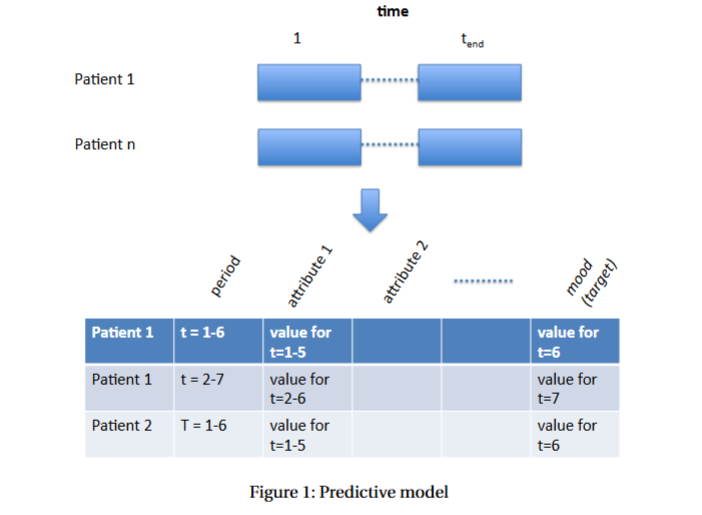

In the end, we end up with a dataset with a number of training instances per patient (as you have a number of time points for which you can train), i.e. an instance that concerns the mood at t=1, t=2, etc. Of course it depends on your choice of the history you consider relevant from what time point you can start predicting (if you use a windows of 5 days of history to create attributes you cannot create training instances before the 6th day). To come to this dataset, you need to:

1. Define attributes that aggregate the history, draw inspiration from the scientific literature.
2. Define the target by averaging the mood over the entire day.
3. Create an instance-based dataset as described in Figure 1.

## TASK 2: CLASSIFICATION (35 POINTS)

Now that we have formed our final dataset, we can move to some modeling. First, we will focus on a classification task.

## TASK 2A: APPLICATION OF CLASSIFICATION ALGORITHMS (25 POINTS)

Basic: Identify the target (i.e. the class you want to predict since the focus is on a classification problem) for your dataset. In case you use the dataset we collected you are free to choose whatever you like. Split up your data in a train and test set and apply two classification algorithms, at least one of them should have been discussed during the lectures. Optimize the hyperparameters of the approaches. Measure and discuss the performance using a performance metric and argue why that is a suitable metric. Describe all steps in your process clearly and fully to make sure it is reproducible.

Advanced: For the advanced assignment you go through the same steps (and shape it into a classification problem with a fixed number of classes for predicting the mood of the next day), however you are required to use two different types of classification algorithms (one algorithm per type), namely one that uses the dataset you formed in Task 1C (e.g. using a random forest) and an algorithm that is inherently temporal (e.g. recurrent neural networks). Also consider a good evaluation setup given the nature of the dataset.

## TASK 2B: WINNING CLASSIFICATION ALGORITHMS (10 POINTS)

Machine learning techniques that are used in Data Mining projects develop quickly these days. One nice way to track these developments is to see which algorithms win competitions on websites such as Kaggle. Your task is to describe the approach of the winner of one of those competitions that focus on a classification tasks. The following sites might serve as starting points:

- http://www.kaggle.com/ - DM competitions
- https://www.kdd.org/kdd-cup - KDD Cup
- Etc. - You should be able to find other relevant competitions by searching the Web.

The main goal is that you can demonstrate that you understand a technique that beats other techniques under certain conditions (specified by the task and data at hand). Here’s what we’d like you to include in the report for this task:

- A description of the competition: what competition, when was it held, what data they were using, what task(s) they were solving, what evaluation measure(s) they used.

- Who was the winner, what technique did they use?

- What was the main idea of the winning approach? (Typically this would come from a paper written by the winners.)

- What makes the winning approach stand out, or how is it different from standard, or non-winning methods?

Particular rules and points to consider:

- A suggestion: 1 page should be more than enough for this task.

- Needless to say, but for the record, please do not copy and paste from papers. Always cite (properly) the source of the paper you are using.

## TASK 3: ASSOCIATION RULES (10 POINTS)

We have seen the APRIORI algorithm during the lecture that targets finding associations in datasets, predicting that an item is likely to be bought given other items that are in the shopping basket already. As mentioned during the lecture, many innovations have been made to improve the APRIORI and other methods. One category of improvements involves grouping of products into higher level product categories (e.g. a Pizza Margherita and Pizza Quattro Formaggio are both pizza’s). Find an approach that aims to do this and describe it. Discuss the pros and cons of such an approach.

## TASK 4: NUMERICAL PREDICTION (10 POINTS)

Similar to Task 2A, apply two machine learning algorithms to your dataset, but now focus on predicting a numerical target (i.e. a regression problem). For the basic dataset this means your choice of two regression algorithms while for the advanced dataset one regression algorithm which is inherently temporal and one which is not. Describe similar details as you have for the classification problem. Highlight the differences you see between the two types of prediction tasks.

## TASK 5: EVALUATION (10 POINTS)

As a final part of the assignment, we will study the impact of your evaluation metrics and their characteristics.

## TASK 5A: CHARACTERISTICS OF EVALUATION METRICS (4 POINTS)

Consider the following two error measures: mean squared error (MSE) and mean absolute error (MAE).

- Write down their corresponding formulae.

- Discuss: Why would someone use one and not the other?

- Describe an example situation (dataset, problem, algorithm perhaps) where using MSE or MAE would give identical results. Justify your answer (some maths may come handy, but clear explanation is also sufficient).

## TASK 5B: IMPACT OF EVALUATION METRICS (6 POINTS)

Apply the MSE and MAE as evaluation metrics to the numerical prediction problem you have worked on under Task 4. Describe how the model behaves under the different characteristics and describe the implications.